In [1]:
print("hi")

hi


In [173]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field


In [174]:
load_dotenv()

True

In [198]:
class sentiment_extraction(BaseModel):
    sentiment_type:Literal['positive','negative'] =Field(description="sentiment type can be either positive or negative only ")




In [199]:
model=ChatGroq(model_name='openai/gpt-oss-20b')


In [200]:
structure_model=model.with_structured_output(sentiment_extraction)

In [201]:
prompt='this product is really good and I am very satisfied with my purchase'
sentiment=structure_model.invoke(prompt)
sentiment

sentiment_extraction(sentiment_type='positive')

In [202]:
s=dict(sentiment)
s['sentiment_type']

'positive'

### Creating the conditional graph

In [214]:
class sentiment_analysis(TypedDict):
    review:str
    sentiment: Literal['positive','negative'] =Field(description="sentiment type can be either positive or negative only ")
    run_diagnosis:str
    reply:str

In [215]:
graph=StateGraph(sentiment_analysis)

In [216]:
def sentiment_extraction_1(state:sentiment_analysis):
    review=state['review']
    sentiment=structure_model.invoke(review)
    print(type(sentiment))
    k=sentiment.sentiment_type
    print(type(k))
    return {'sentiment':k}

def check_sentiment(state:sentiment_analysis)->Literal['positive_sentiment','run_diagnosis']:
    if state['sentiment']=='positive':
        return "positive_sentiment"
    else:
        return "run_diagnosis"

def positive_sentiment(state:sentiment_analysis):
    review=state['review']
    prompt=f'from the customer given review {review}. create a reply to the customer for their review based on their feedback'
    reply=model.invoke(prompt).content
    return {'reply':reply}

def run_diagnosis(state:sentiment_analysis):
    review=state['review']
    prompt=f'for the given product review {review} diagonis the review and extract the insights such a way that we can use them to improve the product'
    run_diagnosis=model.invoke(prompt).content
    return {'run_diagnosis':run_diagnosis}

def negative_sentiment(state:sentiment_analysis):
    review=state['review']
    run_diagnosis=state['run_diagnosis']
    prompt=f'from the customer given review {review} and the diagonis of the review {run_diagnosis}. Create a reply to the customer for their review'
    reply=model.invoke(prompt).content
    return {"reply":reply}





    

In [217]:
graph.add_node('sentiment_extraction_1',sentiment_extraction_1)
graph.add_node('positive_sentiment',positive_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_sentiment',negative_sentiment)

graph.add_edge(START,'sentiment_extraction_1')
graph.add_conditional_edges('sentiment_extraction_1',check_sentiment)
graph.add_edge('positive_sentiment',END)
graph.add_edge('run_diagnosis','negative_sentiment')
graph.add_edge('negative_sentiment',END)



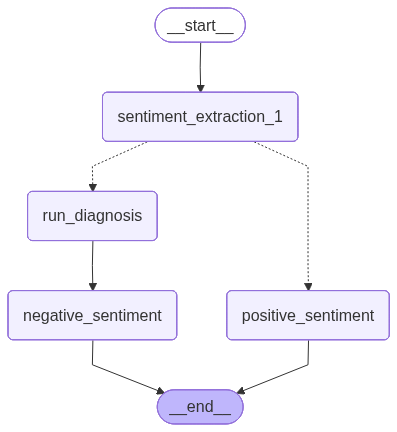

In [218]:
workflow=graph.compile()
workflow

In [208]:
review=""""The kadai feels solid and heats up evenly, so cooking feels steady and the taste is consistent. It is kinda heavy, but once you get used to the weight, it’s actually easy to handle and use. The deep design helps avoid spills, and the size is more than sufficient for daily requirements. It’s simple to maintain too, as long as you dry it well after washing."""

initial_state={'review':review}
output=workflow.invoke(initial_state)
output

<class '__main__.sentiment_extraction'>
<class 'str'>


{'review': '"The kadai feels solid and heats up evenly, so cooking feels steady and the taste is consistent. It is kinda heavy, but once you get used to the weight, it’s actually easy to handle and use. The deep design helps avoid spills, and the size is more than sufficient for daily requirements. It’s simple to maintain too, as long as you dry it well after washing.',
 'sentiment': 'positive',
 'reply': 'Hi there!\n\nThank you so much for taking the time to share your experience with our kadai. We’re thrilled to hear that its solid construction and even heating are making your cooking steady and delicious. It’s great to know that the deep design keeps spills at bay and that the size fits your daily needs perfectly.\n\nWe appreciate your candid note about the weight—many of our customers find the initial heft a bit surprising, but as you mentioned, once you get accustomed to it it becomes quite manageable. If you ever need a lighter alternative or a handy carrying strap, feel free to 

In [209]:
state=sentiment_analysis(**output)
state

{'review': '"The kadai feels solid and heats up evenly, so cooking feels steady and the taste is consistent. It is kinda heavy, but once you get used to the weight, it’s actually easy to handle and use. The deep design helps avoid spills, and the size is more than sufficient for daily requirements. It’s simple to maintain too, as long as you dry it well after washing.',
 'sentiment': 'positive',
 'reply': 'Hi there!\n\nThank you so much for taking the time to share your experience with our kadai. We’re thrilled to hear that its solid construction and even heating are making your cooking steady and delicious. It’s great to know that the deep design keeps spills at bay and that the size fits your daily needs perfectly.\n\nWe appreciate your candid note about the weight—many of our customers find the initial heft a bit surprising, but as you mentioned, once you get accustomed to it it becomes quite manageable. If you ever need a lighter alternative or a handy carrying strap, feel free to 

In [210]:
print(state['reply'])

Hi there!

Thank you so much for taking the time to share your experience with our kadai. We’re thrilled to hear that its solid construction and even heating are making your cooking steady and delicious. It’s great to know that the deep design keeps spills at bay and that the size fits your daily needs perfectly.

We appreciate your candid note about the weight—many of our customers find the initial heft a bit surprising, but as you mentioned, once you get accustomed to it it becomes quite manageable. If you ever need a lighter alternative or a handy carrying strap, feel free to let us know—we’d be happy to help you find the best fit.

Your reminder about drying it well after washing is spot‑on; a quick dry keeps the pan looking new and ready for the next meal. If you have any other tips or questions, we’re all ears.

Thanks again for the positive feedback and for choosing our cookware. We hope to serve you again soon!

Warm regards,  
[Your Name]  
Customer Care Team


In [221]:
review="This product is not non-stick.Product is not upto the mark."
initial_state={'review':review}
output=workflow.invoke(initial_state)
output

<class '__main__.sentiment_extraction'>
<class 'str'>


{'review': 'This product is not non-stick.Product is not upto the mark.',
 'sentiment': 'negative',
 'run_diagnosis': '**Review Summary (Diagnosed Issues)**  \n- **Primary complaint:** The product *does not exhibit a non‑stick surface* as advertised.  \n- **Secondary complaint:** Overall performance is “not up to the mark” – implying sub‑par durability, finish, or functionality.  \n- **Tone:** Negative, short, lacking detail but strongly indicating dissatisfaction with core feature.\n\n---\n\n## 1. Root‑Cause Analysis\n\n| Issue | Likely Causes | Evidence |\n|-------|---------------|----------|\n| **Non‑stick failure** | • Thin or poorly bonded non‑stick coating.<br>• Use of low‑grade PTFE/ceramic material.<br>• Inadequate curing/heat‑treating step. | Review states “not non‑stick” – suggests the coating either peeled off or never adhered. |\n| **Overall quality below expectations** | • Poor material selection (e.g., cheap aluminum base).<br>• Insufficient quality control (QC) checks fo

In [223]:
print(output['reply'])

Dear [Customer Name],

Thank you for taking the time to share your feedback. I’m truly sorry to hear that the product did not meet your expectations, especially regarding the non‑stick feature that is a key part of our promise.

Your comments are extremely valuable to us. We are currently reviewing our coating process and quality‑control procedures to ensure that every item we ship delivers the performance you deserve. In the meantime, we would love the opportunity to make this right for you:

| Option | What we’ll do | Your next step |
|--------|---------------|----------------|
| **Replacement** | Ship a brand‑new unit that has passed our updated non‑stick test. | Reply “Replace me” and we’ll arrange the shipment. |
| **Refund** | Full refund, no questions asked. | Reply “Refund” and we’ll process it immediately. |
| **Extended Warranty** | If you prefer to keep the product, we’ll add a 12‑month warranty covering coating failure. | Reply “Warranty” and we’ll add it to your order. |

